In [1]:
from PVGeo.grids import SurferGridReader
import numpy as np
from matplotlib import pyplot as plt
import segyio
from examples.seismic.fwi.seg_util import get_headers, get_source_dict
from examples.seismic.fwi.zond_util import read_zond
from examples.seismic.fwi.paths import *

In [2]:
dem = SurferGridReader().apply(GRID)

In [3]:
vp = dem.active_scalars

# Reshape to 2D grid (rows, cols)
n_rows = dem.dimensions[1]  # 259
n_cols = dem.dimensions[0]  # 443
shape = dem.dimensions[:-1]
spacing = dem.spacing[:-1]
origin = dem.bounds[0], -dem.bounds[3]
erigin = dem.bounds[1], -dem.bounds[2]
vp_2d = np.flip(vp.reshape(n_rows, n_cols), axis=0).T
x_vp, z_vp = [np.linspace(ori, eri, num=n) for ori, eri, n in zip(origin, erigin, shape)]

In [4]:
header_list = [
    segyio.TraceField.SourceX,
    segyio.TraceField.SourceY,
    segyio.TraceField.SourceSurfaceElevation ,
    segyio.TraceField.GroupX,
    segyio.TraceField.GroupY,
    segyio.TraceField.ReceiverGroupElevation ,
    segyio.TraceField.SourceGroupScalar,
    segyio.TraceField.ElevationScalar
]

remap_string = "pick1,4R,IBM,181 / pick2,4R,IBM,185 / rec_sloc,4R,IBM,197 / sou_sloc,4R,IBM,201"

with segyio.open(DATA_0, "r", ignore_geometry=True) as f:
    data = segyio.tools.collect(f.trace[:])
    hdr = get_headers(f, header_list, remap_string)
    data_dt = segyio.tools.dt(f)
for key in ['SourceX', 'SourceY', 'SourceSurfaceElevation', 'GroupX','GroupY', 'ReceiverGroupElevation']:
    hdr[key] = hdr[key] / 100

with segyio.open(WAVELETS, "r", ignore_geometry=True) as f:
    data_wavelets = segyio.tools.collect(f.trace[:])
    wavelets_dt = segyio.tools.dt(f)

In [5]:
zond_data, geocoord, topo = read_zond(ZOND_RES)

In [6]:
buff = get_source_dict(15, data, hdr, data_wavelets, zond_data)
print(buff)

{'sou_x': np.float64(553140.15), 'sou_z': np.float64(-57.55), 'data': array([[ 0.00000000e+00,  2.09874474e-04,  3.31523450e-04, ...,
        -1.20004574e-02, -1.46226715e-02, -1.82716548e-02],
       [-0.00000000e+00, -1.10668698e-04, -4.09572240e-05, ...,
         4.09276932e-02,  4.31265235e-02,  4.62040715e-02],
       [ 0.00000000e+00, -1.11544530e-07, -1.02140199e-04, ...,
        -6.90101609e-02, -7.83880576e-02, -8.49168599e-02],
       ...,
       [ 0.00000000e+00,  1.87080033e-04,  2.68521289e-05, ...,
         5.80472033e-03,  2.66874628e-03, -1.05714949e-03],
       [ 0.00000000e+00,  9.40386235e-06,  7.34872901e-06, ...,
        -4.40662261e-04, -2.60870758e-04,  3.96245485e-03],
       [-0.00000000e+00, -1.78124770e-04, -5.64563015e-05, ...,
        -2.00071023e-03, -6.55102194e-04, -1.66423721e-04]],
      shape=(108, 550), dtype=float32), 'rec_x': array([  10.289,   20.314,   30.33 ,   40.434,   50.456,   60.279,
         70.251,   80.234,   90.357,  100.373,  110.309, 

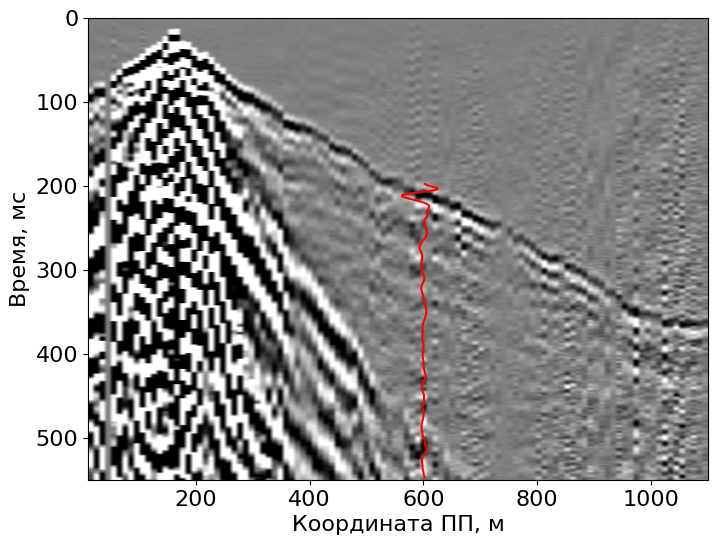

In [7]:
seismogram = buff['data']
rec_x = buff['rec_x']
rec_z = buff['rec_z']

wavelet = buff['wavelet'][:350]
x_wavelet = 600.
amp_wavelet = 25.
wavelet_norm = wavelet/np.amax(wavelet)
wavelet_plot = x_wavelet + wavelet_norm * amp_wavelet
qa = np.quantile(seismogram, 0.9)
plt.imshow(seismogram.T, cmap='grey', vmin=-qa, vmax=qa, extent=[rec_x[0], rec_x[-1], 550, 0])
plt.plot(wavelet_plot, 198+np.arange(0, wavelet.size, wavelets_dt/1e3), c='r')
plt.gca().set_aspect('auto')
plt.ylabel("Время, мс")
plt.xlabel("Координата ПП, м")
plt.show()

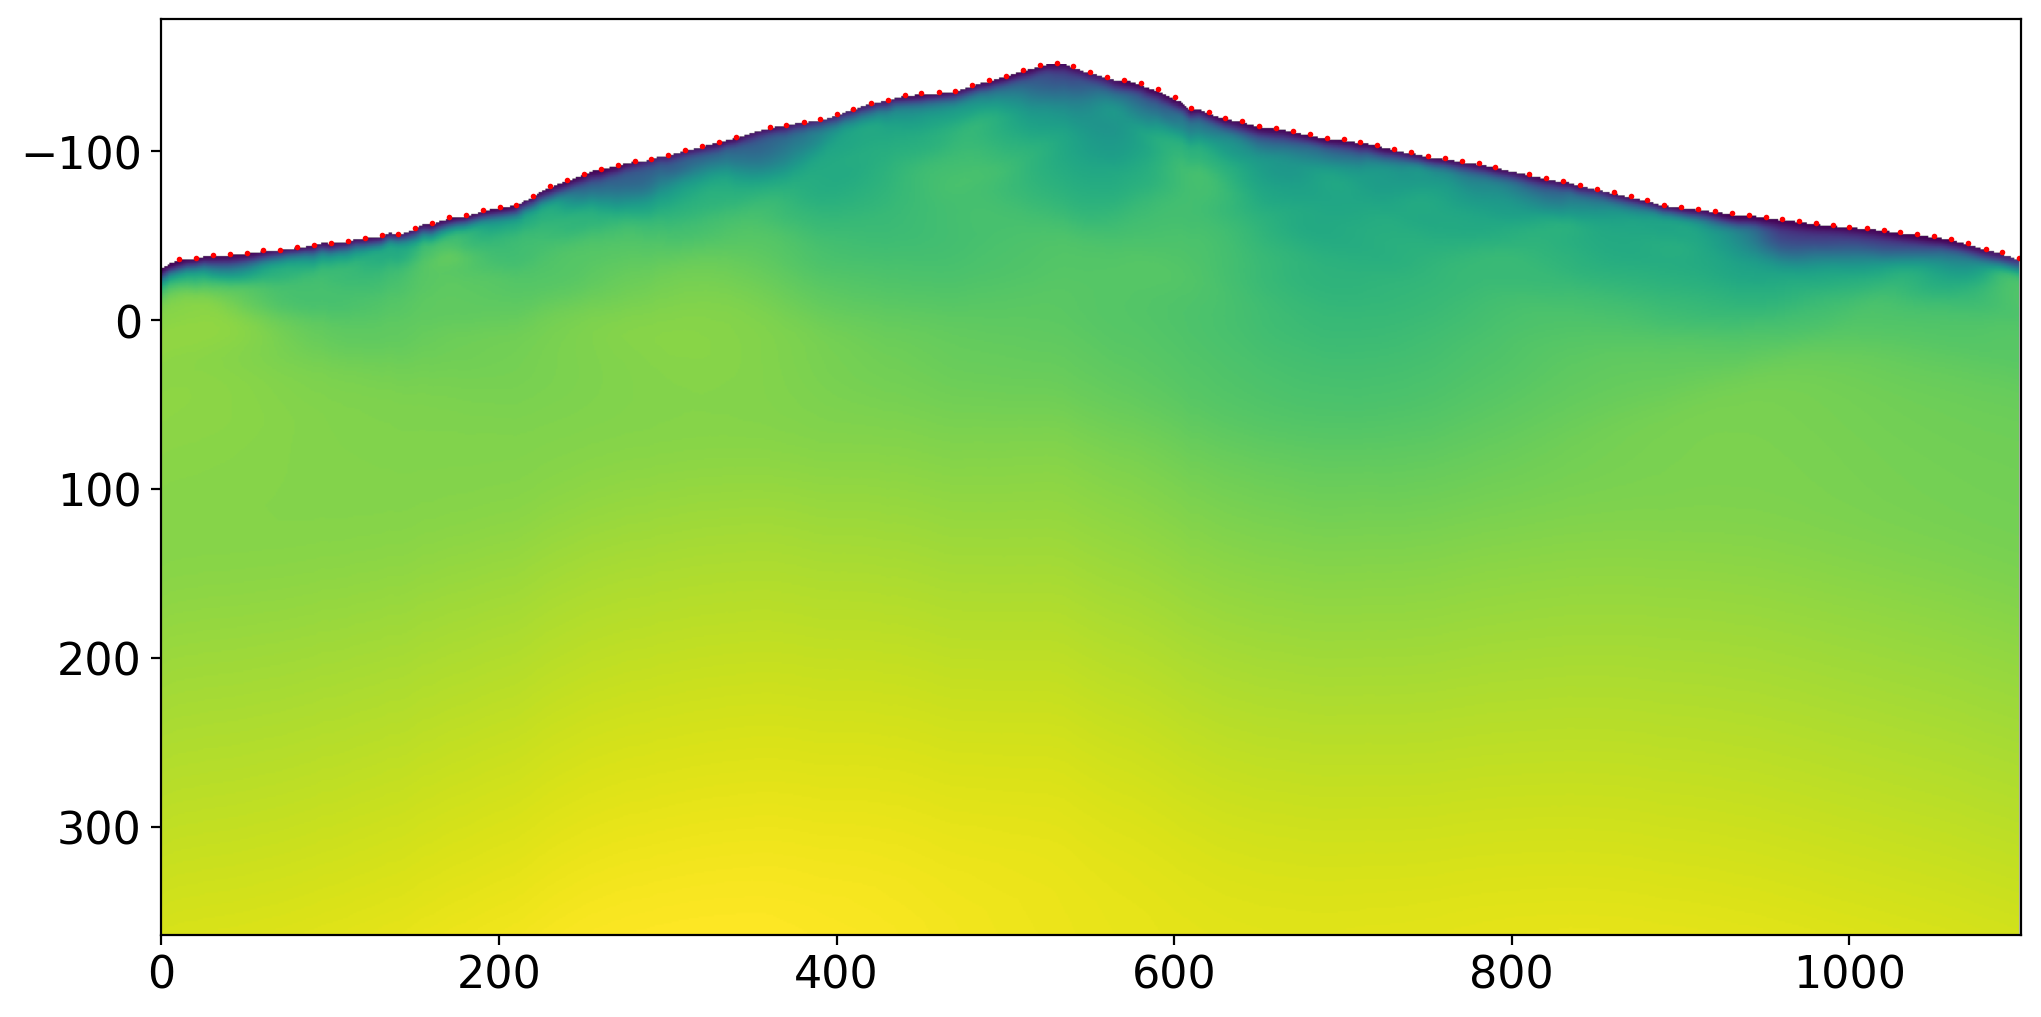

In [8]:
plt.figure(figsize=(12, 12), dpi=200)
plt.imshow(vp_2d.T, extent=[x_vp[0], x_vp[-1], z_vp[-1], z_vp[0]])
plt.scatter(rec_x, rec_z, c='r', s=1)
plt.gca().set_aspect('equal')
plt.show()